# XMIDI Dataset Exploration

In [1]:
from pathlib import Path
from typing import Any, Dict
import math
import warnings

import hydra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from partitura.utils import compute_pianoroll, compute_pitch_class_pianoroll
from partitura.musicanalysis import estimate_key
from omegaconf import OmegaConf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## Configuration

In [2]:
with hydra.initialize(version_base=None, config_path="../configs"):
    cfg = hydra.compose(config_name="config")

print(OmegaConf.to_yaml(cfg))
ROOT = Path("..").resolve()
DATASET_NAME = cfg.data.name

METADATA_CSV = ROOT / cfg.data.paths.labels_output_path
PROCESSED_DIR = ROOT / cfg.data.paths.processed_dir
OUTPUT_DIR = ROOT / "reports" / "figures" / f"{DATASET_NAME}_eda"

MAX_SAMPLES_FOR_FEATURE_TABLE = None        
PARTITURA_SAMPLES_PER_GENRE = 20            
PIANOROLL_TIME_DIV = 8                      

assert METADATA_CSV.exists(), f"Metadata CSV not found: {METADATA_CSV}"
assert PROCESSED_DIR.exists(), f"Processed directory not found: {PROCESSED_DIR}"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset name:", DATASET_NAME)
print("Metadata CSV:", METADATA_CSV.resolve())
print("Processed dir:", PROCESSED_DIR.resolve())
print("Output dir:", OUTPUT_DIR.resolve())

data:
  name: xmidi
  paths:
    dataset_dir: data/raw/xmidi
    processed_dir: data/processed/xmidi
    labels_output_path: data/interim/xmidi_labels.csv
    temp_zip_path: tmp/xmidi.zip
  download:
    file_id: 1qDkSH31x7jN8X-2RyzB9wuxGji4QxYyA
    force: false
    delete_zip: true

Dataset name: xmidi
Metadata CSV: /home/atarsander/University/music_genre_classifier/data/interim/xmidi_labels.csv
Processed dir: /home/atarsander/University/music_genre_classifier/data/processed/xmidi
Output dir: /home/atarsander/University/music_genre_classifier/reports/figures/xmidi_eda


## Load metadata and inspect schema

In [3]:
metadata = pd.read_csv(METADATA_CSV)
metadata.head()

,emotion,genre,sample_id,filename,filepath
0,warm,jazz,8U8Q3FFZ,XMIDI_warm_jazz_8U8Q3FFZ.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_warm_jazz_8...
1,sad,classical,XNP0EPH2,XMIDI_sad_classical_XNP0EPH2.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_sad_classic...
2,exciting,pop,TPMN9L05,XMIDI_exciting_pop_TPMN9L05.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_exciting_po...
3,funny,country,JVZIL3M5,XMIDI_funny_country_JVZIL3M5.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_funny_count...
4,happy,pop,SN74XHLX,XMIDI_happy_pop_SN74XHLX.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_happy_pop_S...


In [4]:
print("Rows:", len(metadata))
print("Columns:", list(metadata.columns))
print()
print(metadata.dtypes)

Rows: 108023
Columns: ['emotion', 'genre', 'sample_id', 'filename', 'filepath']

emotion      str
genre        str
sample_id    str
filename     str
filepath     str
dtype: object


## Missing values checks

In [5]:
required_columns = ["sample_id", "genre"]
missing_required = [col for col in required_columns if col not in metadata.columns]

if missing_required:
    raise ValueError(f"Missing required columns in metadata: {missing_required}")

print("Missing values per column:")
display(metadata.isna().sum().sort_values(ascending=False))

print("\nDuplicate sample_id count:", metadata["sample_id"].duplicated().sum())

Missing values per column:


emotion      0
genre        0
sample_id    0
filename     0
filepath     0
dtype: int64


Duplicate sample_id count: 0


In [6]:
def expected_npz_path(sample_id: str) -> Path:
    return PROCESSED_DIR / f"{sample_id}.npz"

metadata["npz_exists"] = metadata["sample_id"].astype(str).map(lambda sid: expected_npz_path(sid).exists())
print("Missing .npz files:", (~metadata["npz_exists"]).sum())
metadata.loc[~metadata["npz_exists"]].head(10)


Missing .npz files: 0


,emotion,genre,sample_id,filename,filepath,npz_exists


## Class balance

,count
genre,
rock,26708
pop,25582
country,23551
jazz,15862
classical,12660
traditional,3660


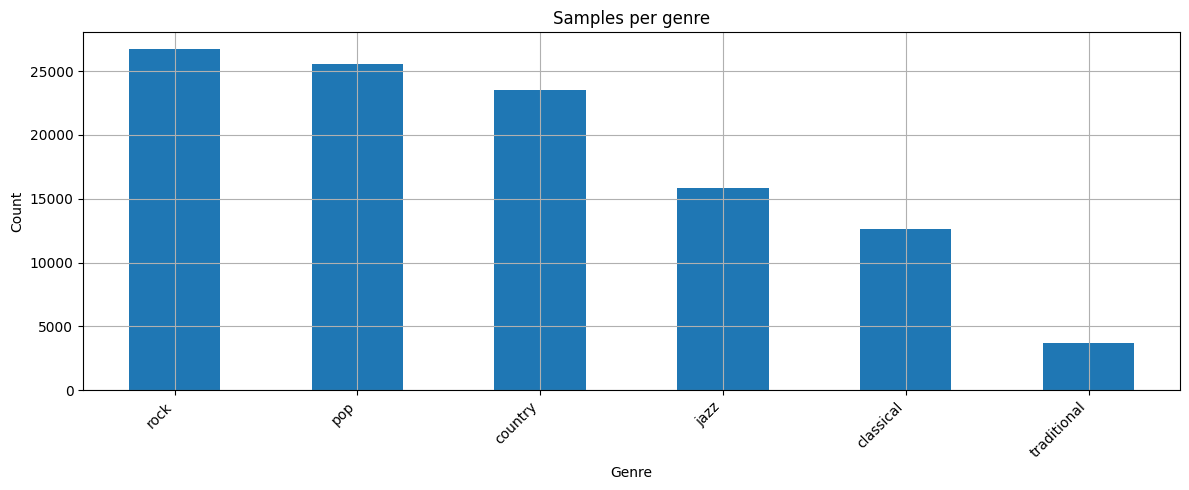

In [ ]:
genre_counts = metadata["genre"].value_counts().sort_values(ascending=False)
display(genre_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.plot(kind="bar", ax=ax)
ax.set_title("Samples per genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_genre_counts.png", dpi=150, bbox_inches="tight")
plt.show()

,count
emotion,
exciting,20948
warm,15090
happy,13291
romantic,12886
funny,12565
sad,9038
angry,8739
lazy,4622
quiet,4431


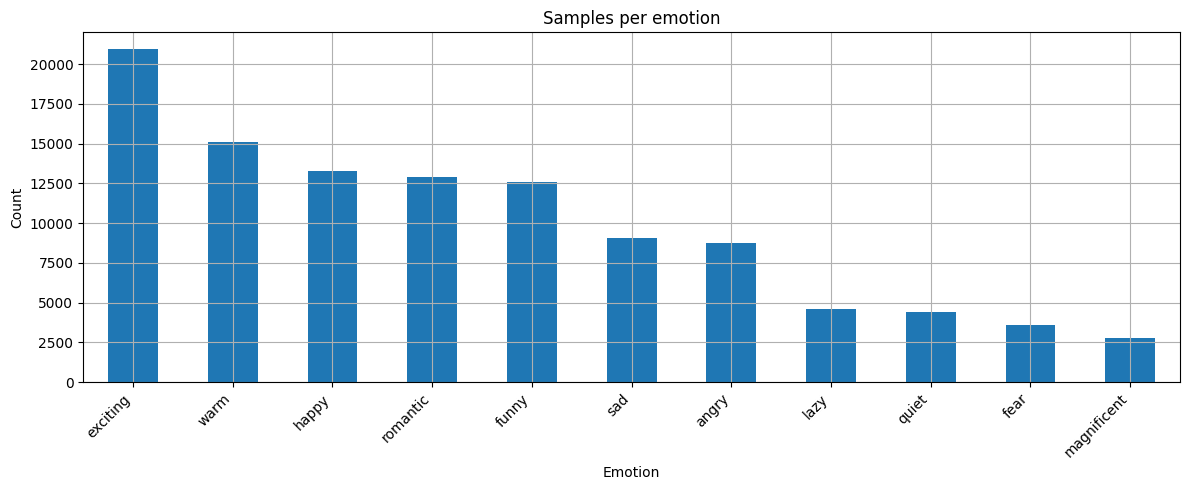

In [ ]:
if "emotion" in metadata.columns:
    emotion_counts = metadata["emotion"].value_counts().sort_values(ascending=False)
    display(emotion_counts.to_frame("count"))

    fig, ax = plt.subplots(figsize=(12, 5))
    emotion_counts.plot(kind="bar", ax=ax)
    ax.set_title("Samples per emotion")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_emotion_counts.png", dpi=150, bbox_inches="tight")
    plt.show()

## Helper functions 
loading note arrays, extracting symbolic features, and reconstructing Partitura representations

In [9]:
def load_note_arrays(npz_path: Path) -> Dict[str, np.ndarray]:
    data = np.load(npz_path)
    return {key: data[key] for key in data.files}


def safe_mean(x: np.ndarray) -> float:
    return float(np.mean(x)) if len(x) else 0.0


def safe_std(x: np.ndarray) -> float:
    return float(np.std(x)) if len(x) else 0.0


def safe_min(x: np.ndarray) -> float:
    return float(np.min(x)) if len(x) else 0.0


def safe_max(x: np.ndarray) -> float:
    return float(np.max(x)) if len(x) else 0.0


def approximate_piece_duration(onset_sec: np.ndarray, duration_sec: np.ndarray) -> float:
    if len(onset_sec) == 0:
        return 0.0
    return float(np.max(onset_sec + duration_sec) - np.min(onset_sec))


def mean_polyphony(onset_sec: np.ndarray, duration_sec: np.ndarray, num_bins: int = 256) -> float:
    if len(onset_sec) == 0:
        return 0.0

    start = np.min(onset_sec)
    end = np.max(onset_sec + duration_sec)
    if end <= start:
        return float(len(onset_sec) > 0)

    grid = np.linspace(start, end, num_bins)
    active_counts = np.zeros_like(grid, dtype=np.int32)

    note_end = onset_sec + duration_sec
    for i, t in enumerate(grid):
        active_counts[i] = np.sum((onset_sec <= t) & (note_end > t))

    return float(np.mean(active_counts))


def to_partitura_note_array(arrays: Dict[str, np.ndarray]) -> np.ndarray:
    n = len(arrays["pitch"])
    dtype = np.dtype([
        ("pitch", "i4"),
        ("onset_sec", "f4"),
        ("duration_sec", "f4"),
        ("velocity", "i4"),
        ("track", "i4"),
        ("channel", "i4"),
    ])
    note_array = np.zeros(n, dtype=dtype)
    note_array["pitch"] = arrays["pitch"]
    note_array["onset_sec"] = arrays["onset_sec"]
    note_array["duration_sec"] = arrays["duration_sec"]
    note_array["velocity"] = arrays["velocity"]
    if "track" in arrays:
        note_array["track"] = arrays["track"]
    if "channel" in arrays:
        note_array["channel"] = arrays["channel"]
    return note_array


def sparse_to_dense(matrix: Any) -> np.ndarray:
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return np.asarray(matrix)


def shannon_entropy(probs: np.ndarray) -> float:
    probs = np.asarray(probs, dtype=np.float64)
    probs = probs[probs > 0]
    if len(probs) == 0:
        return 0.0
    return float(-(probs * np.log2(probs)).sum())


def extract_symbolic_features(arrays: Dict[str, np.ndarray]) -> Dict[str, float]:
    pitch = arrays["pitch"]
    onset = arrays["onset_sec"]
    duration = arrays["duration_sec"]
    velocity = arrays["velocity"]

    onset_sorted = np.sort(onset) if len(onset) else onset
    ioi = np.diff(onset_sorted) if len(onset_sorted) > 1 else np.array([], dtype=np.float32)

    pitch_class_hist = np.bincount(pitch % 12, minlength=12).astype(np.float32) if len(pitch) else np.zeros(12, dtype=np.float32)
    if pitch_class_hist.sum() > 0:
        pitch_class_hist /= pitch_class_hist.sum()

    total_duration = approximate_piece_duration(onset, duration)

    features = {
        "n_notes": float(len(pitch)),
        "piece_duration_sec": total_duration,
        "note_density": float(len(pitch) / total_duration) if total_duration > 0 else 0.0,
        "mean_polyphony": mean_polyphony(onset, duration),
        "pitch_mean": safe_mean(pitch),
        "pitch_std": safe_std(pitch),
        "pitch_min": safe_min(pitch),
        "pitch_max": safe_max(pitch),
        "pitch_range": safe_max(pitch) - safe_min(pitch) if len(pitch) else 0.0,
        "duration_mean": safe_mean(duration),
        "duration_std": safe_std(duration),
        "duration_sum": float(np.sum(duration)) if len(duration) else 0.0,
        "velocity_mean": safe_mean(velocity),
        "velocity_std": safe_std(velocity),
        "ioi_mean": safe_mean(ioi),
        "ioi_std": safe_std(ioi),
        "n_unique_tracks": float(len(np.unique(arrays["track"]))) if "track" in arrays else 0.0,
        "n_unique_channels": float(len(np.unique(arrays["channel"]))) if "channel" in arrays else 0.0,
    }

    for i, value in enumerate(pitch_class_hist):
        features[f"pitch_class_{i}"] = float(value)

    return features


def extract_partitura_features(arrays: Dict[str, np.ndarray], time_div: int = 8) -> Dict[str, Any]:
    note_info = to_partitura_note_array(arrays)

    pr = compute_pianoroll(
        note_info,
        time_unit="sec",
        time_div=time_div,
        piano_range=True,
        remove_silence=True,
        binary=False,
    )
    pr = sparse_to_dense(pr).astype(np.float32)

    pcpr = compute_pitch_class_pianoroll(
        note_info,
        normalize=True,
        time_unit="sec",
        time_div=time_div,
        remove_silence=True,
        binary=False,
    )
    pcpr = sparse_to_dense(pcpr).astype(np.float32)

    key_label = estimate_key(note_info)

    if pr.size:
        active_pitches = (pr > 0).sum(axis=0)
        pr_active_pitches_mean = float(np.mean(active_pitches))
        pr_active_pitches_std = float(np.std(active_pitches))
    else:
        pr_active_pitches_mean = 0.0
        pr_active_pitches_std = 0.0

    if pcpr.size:
        timestep_entropy = [shannon_entropy(pcpr[:, i]) for i in range(pcpr.shape[1])]
        pcpr_entropy_mean = float(np.mean(timestep_entropy))
        pcpr_entropy_std = float(np.std(timestep_entropy))
        pcpr_peak_mean = float(np.mean(np.max(pcpr, axis=0)))
        pcpr_profile = pcpr.mean(axis=1)
        if pcpr_profile.sum() > 0:
            pcpr_profile = pcpr_profile / pcpr_profile.sum()
    else:
        pcpr_entropy_mean = 0.0
        pcpr_entropy_std = 0.0
        pcpr_peak_mean = 0.0
        pcpr_profile = np.zeros(12, dtype=np.float32)

    features: Dict[str, Any] = {
        "estimated_key": key_label,
        "pr_time_steps": float(pr.shape[1]) if pr.ndim == 2 else 0.0,
        "pr_active_pitches_mean": pr_active_pitches_mean,
        "pr_active_pitches_std": pr_active_pitches_std,
        "pcpr_entropy_mean": pcpr_entropy_mean,
        "pcpr_entropy_std": pcpr_entropy_std,
        "pcpr_peak_mean": pcpr_peak_mean,
        "pianoroll_matrix": pr,
        "pcpr_matrix": pcpr,
    }

    for i, value in enumerate(pcpr_profile):
        features[f"pcpr_profile_{i}"] = float(value)

    return features

## Build a feature table from all processed files

In [10]:
rows = []

usable_metadata = metadata.loc[metadata["npz_exists"]].copy()

if MAX_SAMPLES_FOR_FEATURE_TABLE is not None:
    usable_metadata = (
        usable_metadata.groupby("genre", group_keys=False)
        .apply(lambda df: df.sample(min(len(df), MAX_SAMPLES_FOR_FEATURE_TABLE), random_state=42))
        .reset_index(drop=True)
    )

for row in usable_metadata.itertuples(index=False):
    sample_id = str(row.sample_id)
    arrays = load_note_arrays(expected_npz_path(sample_id))
    features = extract_symbolic_features(arrays)

    feature_row = dict(features)
    feature_row["sample_id"] = sample_id
    feature_row["genre"] = row.genre
    if hasattr(row, "emotion"):
        feature_row["emotion"] = row.emotion

    rows.append(feature_row)

features_df = pd.DataFrame(rows)
print("Feature rows:", len(features_df))
features_df.head()

Feature rows: 108023


,n_notes,piece_duration_sec,note_density,mean_polyphony,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,duration_mean,...,pitch_class_5,pitch_class_6,pitch_class_7,pitch_class_8,pitch_class_9,pitch_class_10,pitch_class_11,sample_id,genre,emotion
0,4395.0,272.647247,16.119730,6.683594,50.488055,11.803069,28.0,81.0,53.0,0.419297,...,0.065757,0.033220,0.046189,0.032537,0.196360,0.121729,0.137884,8U8Q3FFZ,jazz,warm
1,312.0,68.382393,4.562578,1.769531,62.256410,6.853197,45.0,74.0,29.0,0.386232,...,0.182692,0.025641,0.153846,0.006410,0.108974,0.016026,0.102564,XNP0EPH2,classical,sad
2,4207.0,153.466492,27.413150,4.367188,46.787972,9.939308,28.0,68.0,40.0,0.161451,...,0.008557,0.200143,0.004516,0.137865,0.003565,0.111956,0.092703,TPMN9L05,pop,exciting
3,4898.0,214.474930,22.837168,2.132812,51.409555,12.720818,31.0,93.0,62.0,0.087847,...,0.019804,0.228256,0.033075,0.161086,0.105757,0.003879,0.008167,JVZIL3M5,country,funny
4,3722.0,162.353043,22.925348,2.718750,58.023912,21.216198,17.0,89.0,72.0,0.119226,...,0.048898,0.178667,0.000000,0.021494,0.108006,0.037883,0.075497,SN74XHLX,pop,happy


## Summary statistics

In [11]:
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
summary = features_df[numeric_cols].describe().T.sort_values("std", ascending=False)
display(summary.head(25))


,count,mean,std,min,25%,50%,75%,max
n_notes,108023.0,3519.614971,2206.951461,8.000000,1884.000000,3165.000000,4706.000000,25364.000000
duration_sum,108023.0,826.081770,509.971003,4.868701,473.634750,744.974182,1081.150879,25328.648438
piece_duration_sec,108023.0,175.563635,60.021774,2.450493,131.092529,175.462296,220.584167,1097.170044
velocity_mean,108023.0,88.516544,15.731560,40.000000,77.539987,88.229946,99.565619,126.000000
pitch_range,108023.0,55.197171,12.115073,0.000000,48.000000,55.000000,62.000000,127.000000
note_density,108023.0,19.821897,10.344404,0.287147,12.475461,18.334805,25.320444,131.332841
pitch_max,108023.0,84.237922,9.603196,30.000000,79.000000,84.000000,89.000000,127.000000
velocity_std,108023.0,16.190368,7.706492,0.000000,11.973500,17.227432,21.512016,42.990369
pitch_min,108023.0,29.040751,6.764774,0.000000,26.000000,28.000000,33.000000,77.000000
pitch_mean,108023.0,54.157521,5.945460,19.351724,50.493789,53.909007,57.637652,111.021676


## Distribution plots for core features

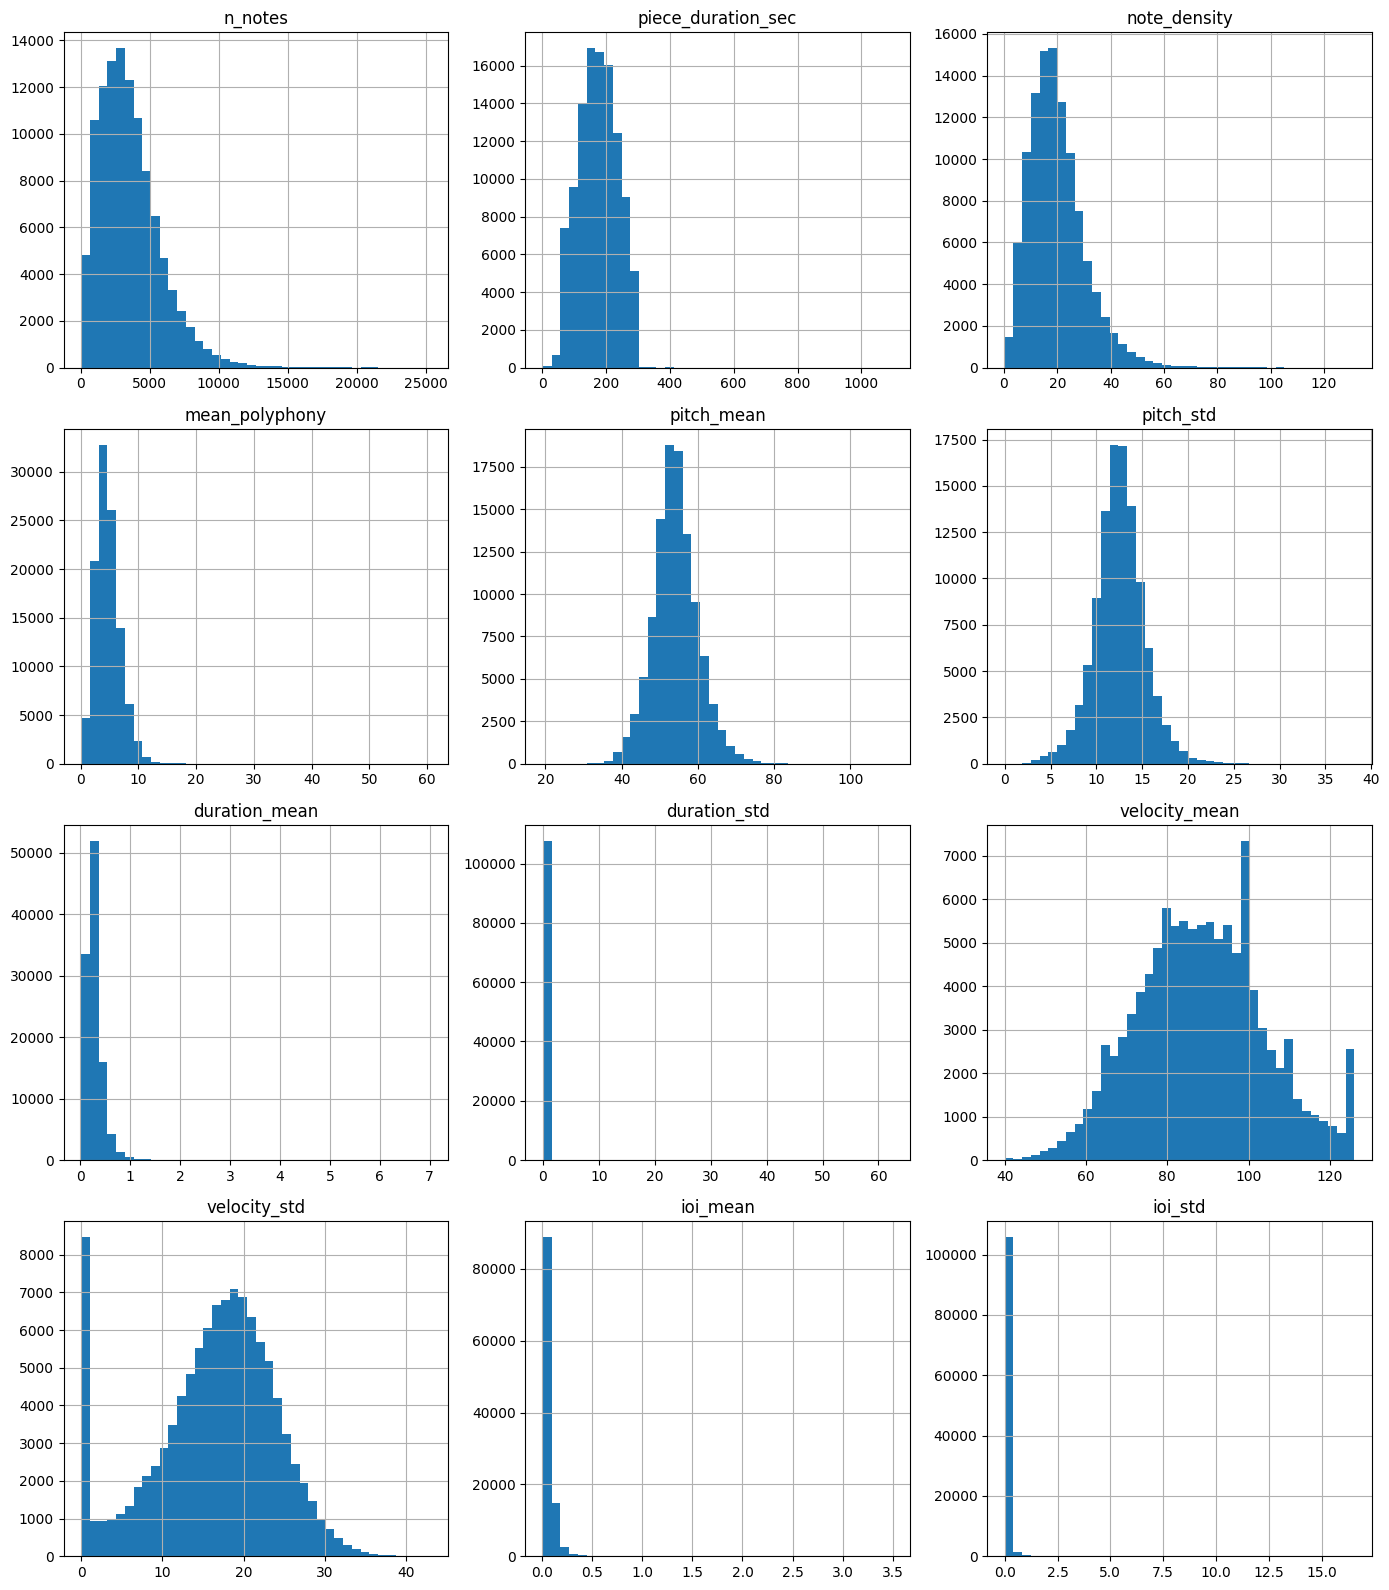

In [ ]:
core_features = [
    "n_notes",
    "piece_duration_sec",
    "note_density",
    "mean_polyphony",
    "pitch_mean",
    "pitch_std",
    "duration_mean",
    "duration_std",
    "velocity_mean",
    "velocity_std",
    "ioi_mean",
    "ioi_std",
]

n_cols = 3
n_rows = math.ceil(len(core_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, core_features):
    ax.hist(features_df[feature].dropna(), bins=40)
    ax.set_title(feature)

for ax in axes[len(core_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_core_features_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-genre feature comparison

In [13]:
genre_feature_means = (
    features_df.groupby("genre")[core_features]
    .mean()
    .sort_index()
)
display(genre_feature_means)


,n_notes,piece_duration_sec,note_density,mean_polyphony,pitch_mean,pitch_std,duration_mean,duration_std,velocity_mean,velocity_std,ioi_mean,ioi_std
genre,,,,,,,,,,,,
classical,1805.998341,145.190654,12.302544,3.494235,60.528941,11.440852,0.361900,0.301852,86.518661,11.914685,0.125982,0.226463
country,3770.028279,184.909489,20.560630,5.425042,52.683210,12.386818,0.289611,0.333815,87.956729,17.818312,0.058292,0.110850
jazz,3671.741710,177.903365,20.668232,4.793999,54.140773,13.218394,0.267539,0.324530,84.927009,18.183516,0.063073,0.119798
pop,4396.405168,180.539834,24.206207,4.795600,53.965213,13.264378,0.233358,0.293125,88.531999,17.809710,0.053582,0.099726
rock,3345.080425,178.086064,18.775618,4.481395,52.010780,12.136184,0.280986,0.300867,92.119923,14.528268,0.073392,0.127970
traditional,2321.606831,157.157849,14.400350,4.044163,58.687512,11.665335,0.372272,0.312920,88.183261,12.676819,0.110656,0.178194


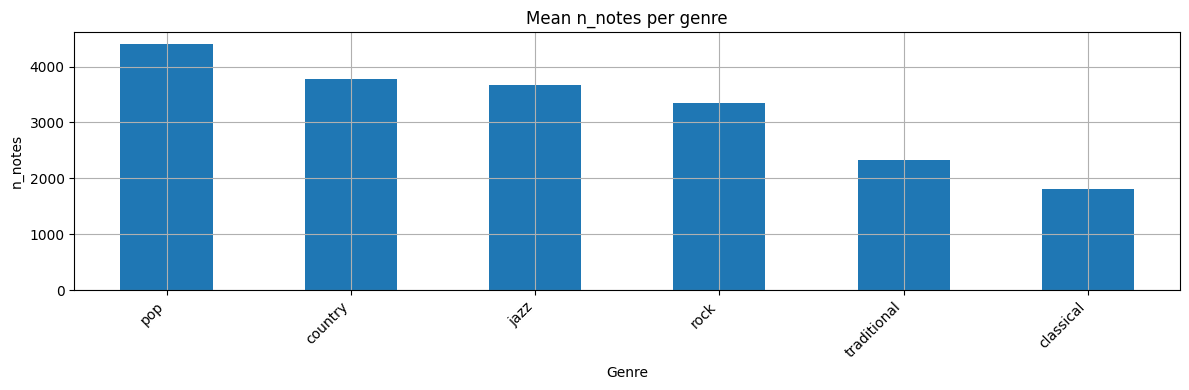

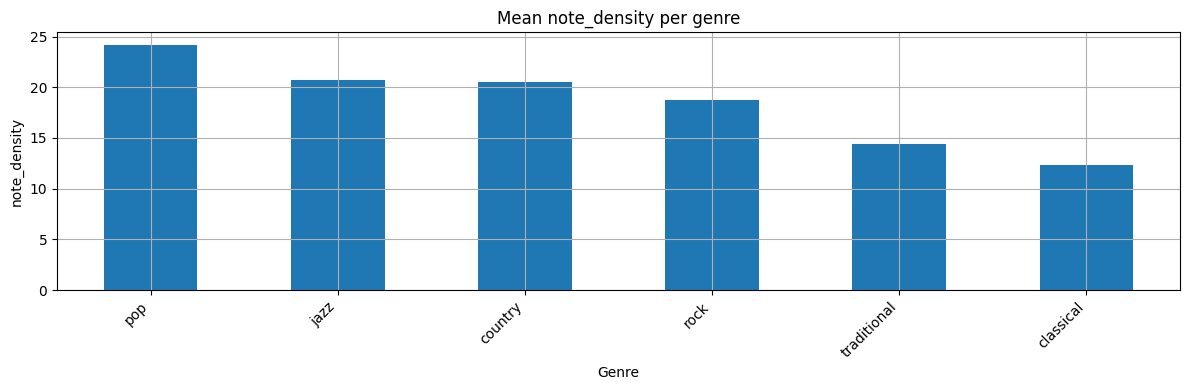

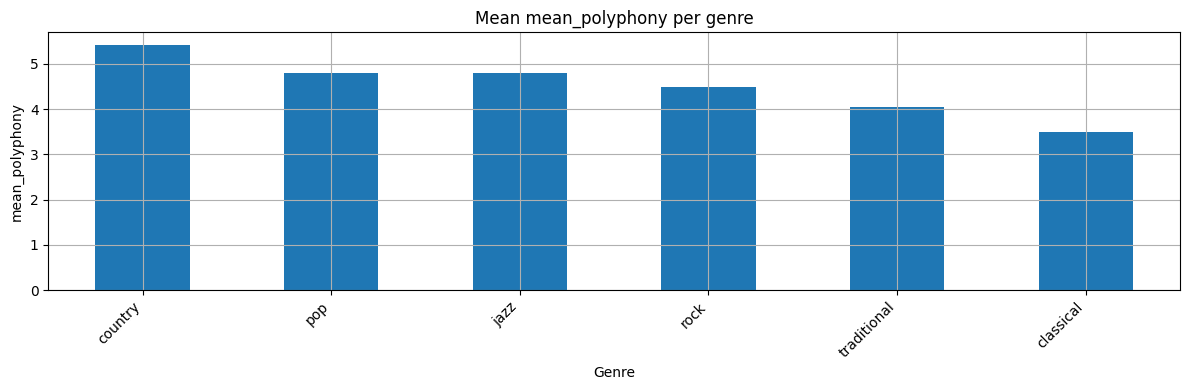

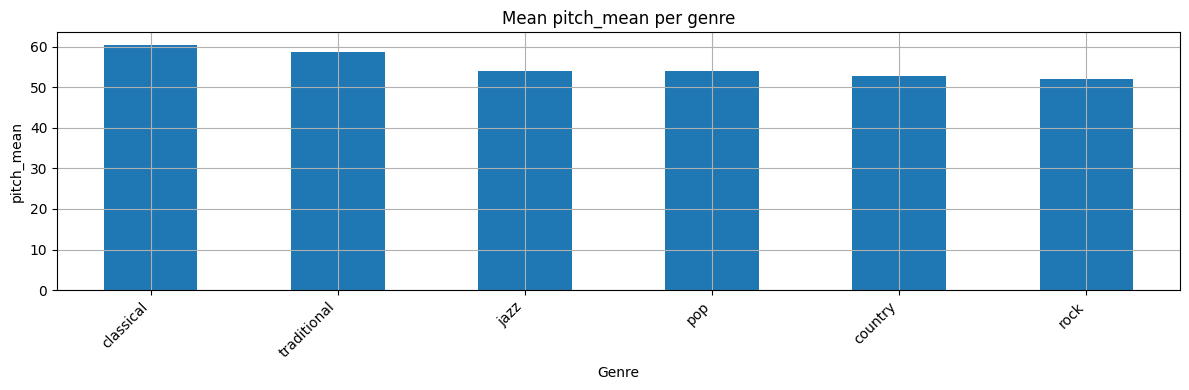

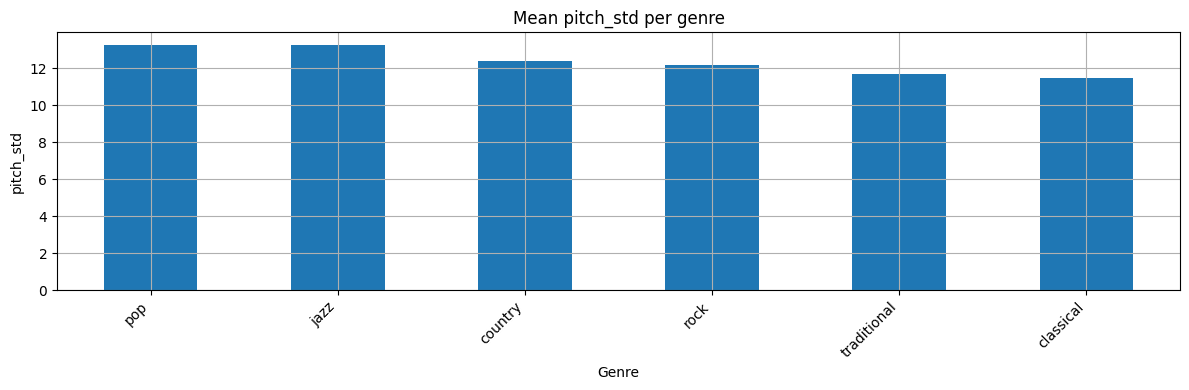

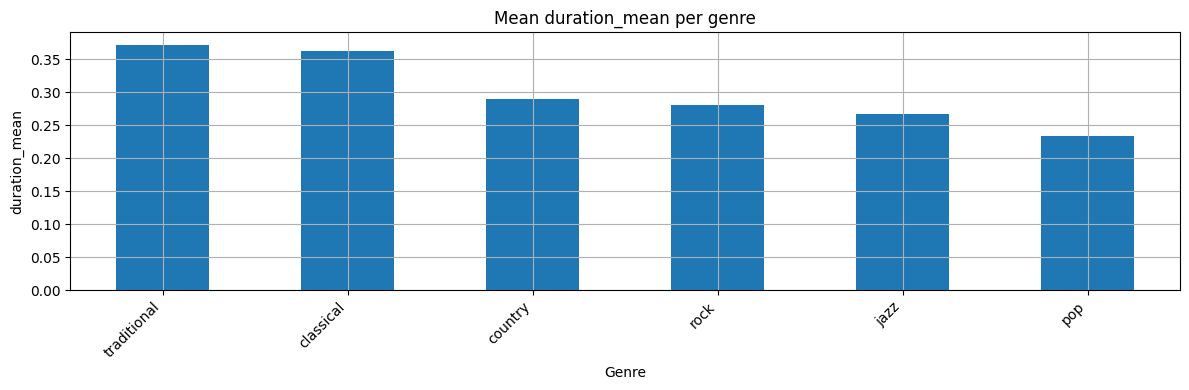

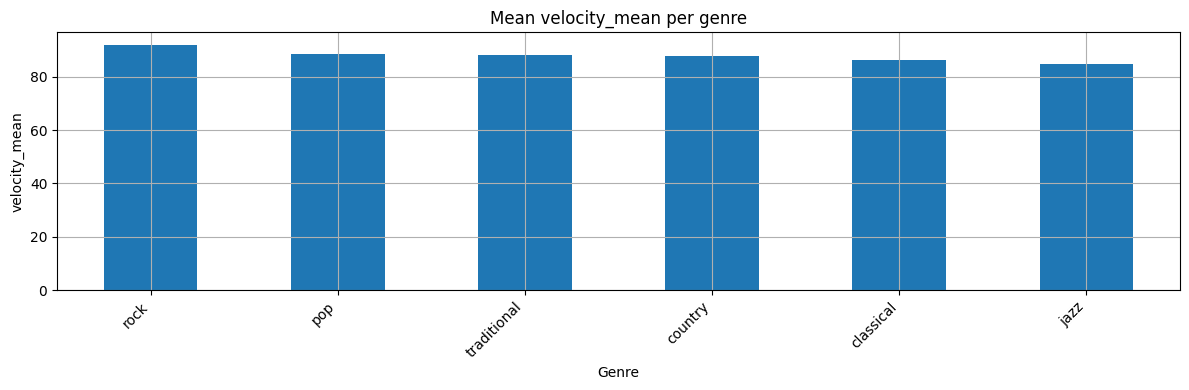

In [ ]:
selected = ["n_notes", "note_density", "mean_polyphony", "pitch_mean", "pitch_std", "duration_mean", "velocity_mean"]

for feature in selected:
    fig, ax = plt.subplots(figsize=(12, 4))
    (
        features_df.groupby("genre")[feature]
        .mean()
        .sort_values(ascending=False)
        .plot(kind="bar", ax=ax)
    )
    ax.set_title(f"Mean {feature} per genre")
    ax.set_xlabel("Genre")
    ax.set_ylabel(feature)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"04_genre_{feature}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Pitch-class profiles

,pitch_class_0,pitch_class_1,pitch_class_2,pitch_class_3,pitch_class_4,pitch_class_5,pitch_class_6,pitch_class_7,pitch_class_8,pitch_class_9,pitch_class_10,pitch_class_11
genre,,,,,,,,,,,,
classical,0.114813,0.044448,0.122970,0.054830,0.097490,0.082596,0.071530,0.115206,0.044688,0.107528,0.069236,0.074665
country,0.103407,0.047867,0.105200,0.051174,0.092561,0.053801,0.177147,0.078812,0.049502,0.089525,0.056905,0.094099
jazz,0.106338,0.047129,0.098260,0.081094,0.083697,0.061901,0.139893,0.077114,0.054220,0.087033,0.078728,0.084595
pop,0.103248,0.045905,0.094995,0.062690,0.085126,0.055188,0.169994,0.069717,0.058932,0.089219,0.083212,0.081776
rock,0.116581,0.043315,0.118251,0.051432,0.102806,0.056101,0.133460,0.082576,0.046134,0.097183,0.059981,0.092180
traditional,0.116201,0.033691,0.133582,0.046422,0.100085,0.071165,0.087078,0.122599,0.036482,0.112708,0.059994,0.079993


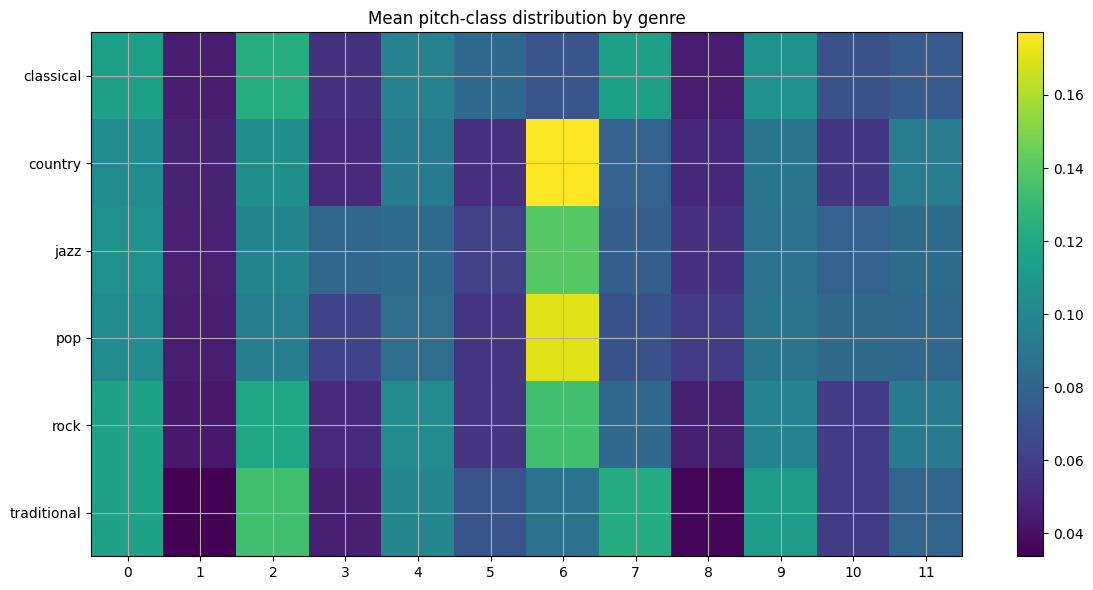

In [ ]:
pitch_class_cols = [f"pitch_class_{i}" for i in range(12)]
pitch_class_by_genre = features_df.groupby("genre")[pitch_class_cols].mean()

display(pitch_class_by_genre)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pitch_class_by_genre.values, aspect="auto")
ax.set_xticks(range(12))
ax.set_xticklabels(range(12))
ax.set_yticks(range(len(pitch_class_by_genre.index)))
ax.set_yticklabels(pitch_class_by_genre.index)
ax.set_title("Mean pitch-class distribution by genre")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_pitch_class_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()

## Partitura-based musicological analysis subset

In [16]:
rows = []
for genre, df in usable_metadata.reset_index().groupby("genre"):
    rows.append(df.sample(min(len(df), PARTITURA_SAMPLES_PER_GENRE), random_state=42))

partitura_subset = pd.concat(rows, ignore_index=True)

print("Rows in Partitura analysis subset:", len(partitura_subset))
display(partitura_subset.head())

Rows in Partitura analysis subset: 120


,index,emotion,genre,sample_id,filename,filepath,npz_exists
0,10798,funny,classical,U2R7JF6Z,XMIDI_funny_classical_U2R7JF6Z.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_funny_class...,True
1,76297,angry,classical,3NULGRH8,XMIDI_angry_classical_3NULGRH8.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_angry_class...,True
2,96676,happy,classical,646TG28Z,XMIDI_happy_classical_646TG28Z.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_happy_class...,True
3,106189,funny,classical,QZAIMAR9,XMIDI_funny_classical_QZAIMAR9.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_funny_class...,True
4,86078,fear,classical,ANUYUI0C,XMIDI_fear_classical_ANUYUI0C.midi,data/raw/xmidi/XMIDI_Dataset/XMIDI_fear_classi...,True


## Compute richer Partitura representations and descriptors

In [17]:
partitura_rows = []

for row in partitura_subset.itertuples(index=False):
    sample_id = str(row.sample_id)
    arrays = load_note_arrays(expected_npz_path(sample_id))
    partitura_feats = extract_partitura_features(arrays, time_div=PIANOROLL_TIME_DIV)

    record = {
        "sample_id": sample_id,
        "genre": row.genre,
        "estimated_key": partitura_feats["estimated_key"],
        "pr_time_steps": partitura_feats["pr_time_steps"],
        "pr_active_pitches_mean": partitura_feats["pr_active_pitches_mean"],
        "pr_active_pitches_std": partitura_feats["pr_active_pitches_std"],
        "pcpr_entropy_mean": partitura_feats["pcpr_entropy_mean"],
        "pcpr_entropy_std": partitura_feats["pcpr_entropy_std"],
        "pcpr_peak_mean": partitura_feats["pcpr_peak_mean"],
        "pianoroll_matrix": partitura_feats["pianoroll_matrix"],
        "pcpr_matrix": partitura_feats["pcpr_matrix"],
    }

    for i in range(12):
        record[f"pcpr_profile_{i}"] = partitura_feats[f"pcpr_profile_{i}"]

    partitura_rows.append(record)

partitura_df = pd.DataFrame(partitura_rows)
print("Computed Partitura descriptors for:", len(partitura_df), "samples")
partitura_df.head()

Computed Partitura descriptors for: 120 samples


,sample_id,genre,estimated_key,pr_time_steps,pr_active_pitches_mean,pr_active_pitches_std,pcpr_entropy_mean,pcpr_entropy_std,pcpr_peak_mean,pianoroll_matrix,...,pcpr_profile_2,pcpr_profile_3,pcpr_profile_4,pcpr_profile_5,pcpr_profile_6,pcpr_profile_7,pcpr_profile_8,pcpr_profile_9,pcpr_profile_10,pcpr_profile_11
0,U2R7JF6Z,classical,E,1855.0,1.943396,0.966015,0.547506,0.565952,0.739398,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,0.084725,0.034521,0.196919,0.002227,0.104770,0.002227,0.039532,0.221325,0.019209,0.257981
1,3NULGRH8,classical,Eb,871.0,2.061998,0.701525,0.615833,0.517719,0.703912,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,0.017218,0.262300,0.000579,0.044762,0.000000,0.049633,0.186568,0.000000,0.312618,0.000000
2,646TG28Z,classical,Cm,306.0,6.901961,1.872626,1.482853,0.509965,0.447865,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,0.057927,0.026778,0.028587,0.136934,0.122472,0.157637,0.016975,0.015695,0.121134,0.113231
3,QZAIMAR9,classical,Bm,1058.0,1.267486,1.080547,0.310403,0.516172,0.602968,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,0.198784,0.047898,0.030550,0.074310,0.063086,0.172685,0.012250,0.090093,0.084038,0.001797
4,ANUYUI0C,classical,G,678.0,1.823009,0.881438,0.433853,0.574609,0.798870,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,0.240675,0.000000,0.020883,0.000000,0.056566,0.379120,0.029728,0.095238,0.000000,0.114640


## Estimated key distribution by genre

,genre,estimated_key,count
0,classical,A,1
1,classical,Bb,1
2,classical,Bm,1
3,classical,C,1
4,classical,Cm,1
5,classical,D,4
6,classical,Dm,1
7,classical,E,1
8,classical,Eb,4
9,classical,Em,1


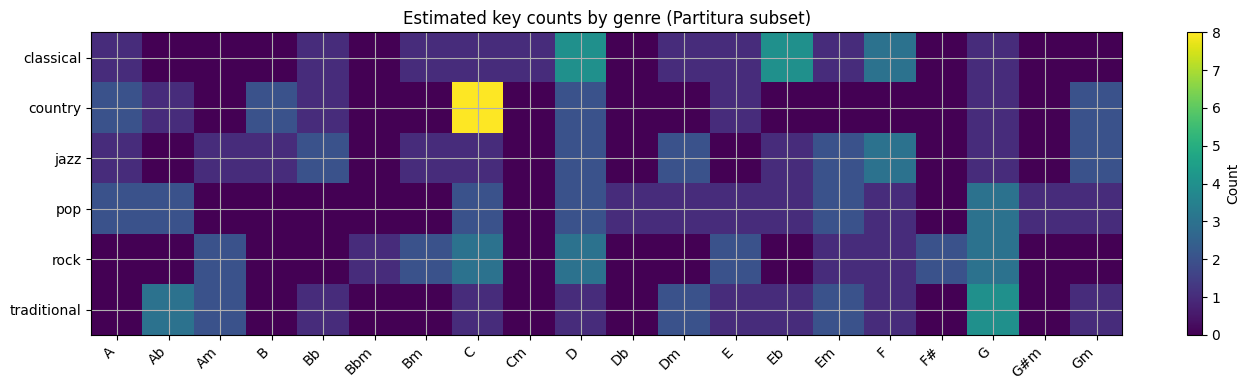

In [ ]:
key_counts = (
    partitura_df.groupby(["genre", "estimated_key"])
    .size()
    .rename("count")
    .reset_index()
)

display(key_counts.head(20))

pivot = key_counts.pivot(index="genre", columns="estimated_key", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(14, max(4, 0.45 * len(pivot.index))))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Estimated key counts by genre (Partitura subset)")
fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_key_counts_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()

## Time-normalized pitch-class profiles with Partitura

,pcpr_profile_0,pcpr_profile_1,pcpr_profile_2,pcpr_profile_3,pcpr_profile_4,pcpr_profile_5,pcpr_profile_6,pcpr_profile_7,pcpr_profile_8,pcpr_profile_9,pcpr_profile_10,pcpr_profile_11
genre,,,,,,,,,,,,
classical,0.105518,0.027864,0.133877,0.073617,0.075371,0.080343,0.047624,0.135137,0.047366,0.109873,0.096398,0.067013
country,0.130376,0.035124,0.114345,0.038278,0.118087,0.074949,0.052200,0.159529,0.040237,0.114115,0.034081,0.088679
jazz,0.116641,0.041886,0.135294,0.052272,0.072959,0.105485,0.050255,0.136133,0.041722,0.111808,0.067147,0.068398
pop,0.114723,0.063435,0.118143,0.049561,0.099192,0.066547,0.048306,0.127214,0.061865,0.106822,0.065389,0.078803
rock,0.120081,0.067003,0.128026,0.017595,0.111463,0.066170,0.062269,0.145215,0.027584,0.123718,0.030704,0.100171
traditional,0.104709,0.028647,0.148203,0.075715,0.090222,0.065413,0.036542,0.136267,0.053607,0.123245,0.068256,0.069174


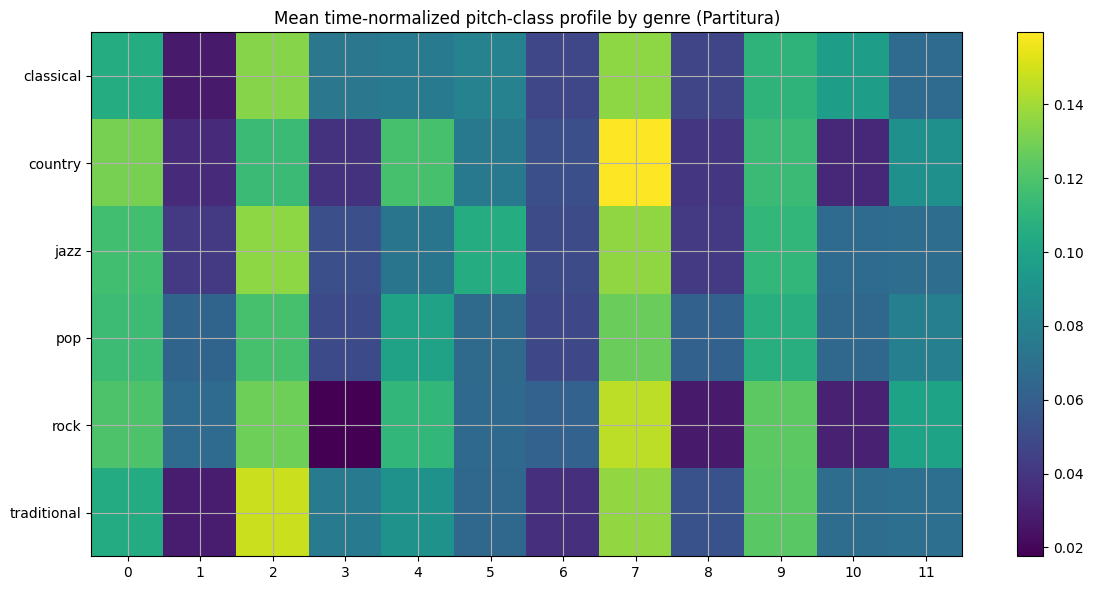

In [ ]:
pcpr_profile_cols = [f"pcpr_profile_{i}" for i in range(12)]
pcpr_profile_by_genre = partitura_df.groupby("genre")[pcpr_profile_cols].mean()

display(pcpr_profile_by_genre)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pcpr_profile_by_genre.values, aspect="auto")
ax.set_xticks(range(12))
ax.set_xticklabels(range(12))
ax.set_yticks(range(len(pcpr_profile_by_genre.index)))
ax.set_yticklabels(pcpr_profile_by_genre.index)
ax.set_title("Mean time-normalized pitch-class profile by genre (Partitura)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_pcpr_profile_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()

## Representative piano-roll views by genre

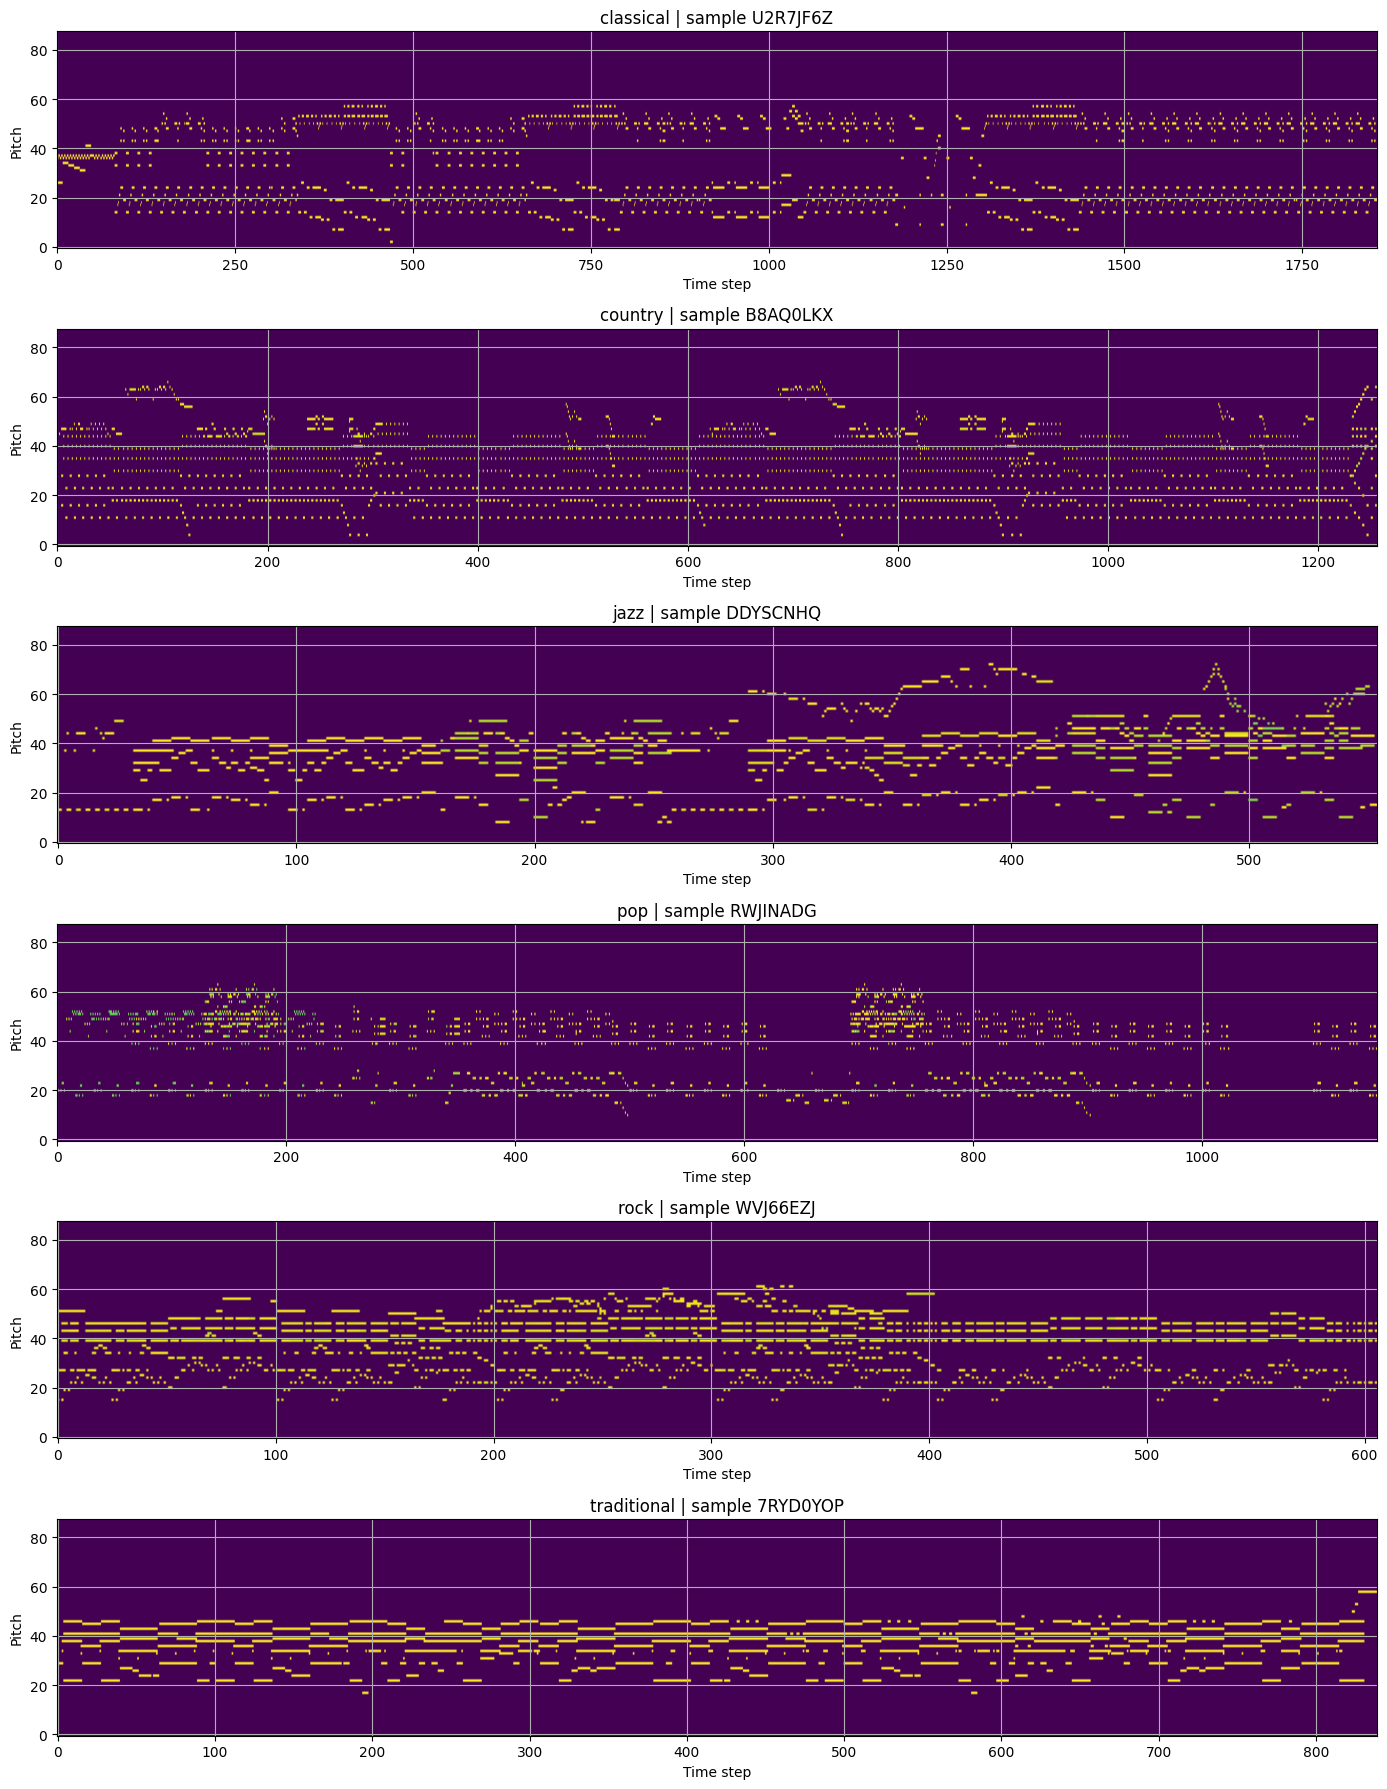

In [ ]:
representatives = (
    partitura_df.groupby("genre", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

n_show = min(len(representatives), 6)
fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), squeeze=False)

for ax, row in zip(axes.flatten(), representatives.itertuples(index=False)):
    pr = row.pianoroll_matrix
    if pr.size == 0:
        ax.set_title(f"{row.genre} | {row.sample_id} (empty piano roll)")
        ax.axis("off")
        continue

    ax.imshow(np.log1p(pr), aspect="auto", origin="lower")
    ax.set_title(f"{row.genre} | sample {row.sample_id}")
    ax.set_ylabel("Pitch")
    ax.set_xlabel("Time step")

for ax in axes.flatten()[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_representative_pianorolls.png", dpi=150, bbox_inches="tight")
plt.show()

## Partitura-derived descriptor summary

In [21]:
partitura_numeric_cols = [
    "pr_time_steps",
    "pr_active_pitches_mean",
    "pr_active_pitches_std",
    "pcpr_entropy_mean",
    "pcpr_entropy_std",
    "pcpr_peak_mean",
]

display(partitura_df.groupby("genre")[partitura_numeric_cols].mean().sort_index())

,pr_time_steps,pr_active_pitches_mean,pr_active_pitches_std,pcpr_entropy_mean,pcpr_entropy_std,pcpr_peak_mean
genre,,,,,,
classical,1139.85,3.392495,1.605972,1.054116,0.613772,0.550586
country,1573.85,4.164838,1.692337,1.185938,0.548815,0.542815
jazz,1530.65,4.177362,1.980940,1.286267,0.677877,0.536741
pop,1369.55,3.775534,1.726911,1.149551,0.617224,0.535503
rock,1450.30,3.263497,1.430884,0.929255,0.580830,0.619492
traditional,1157.80,3.488836,1.455092,1.073490,0.585432,0.577418


## Correlation analysis

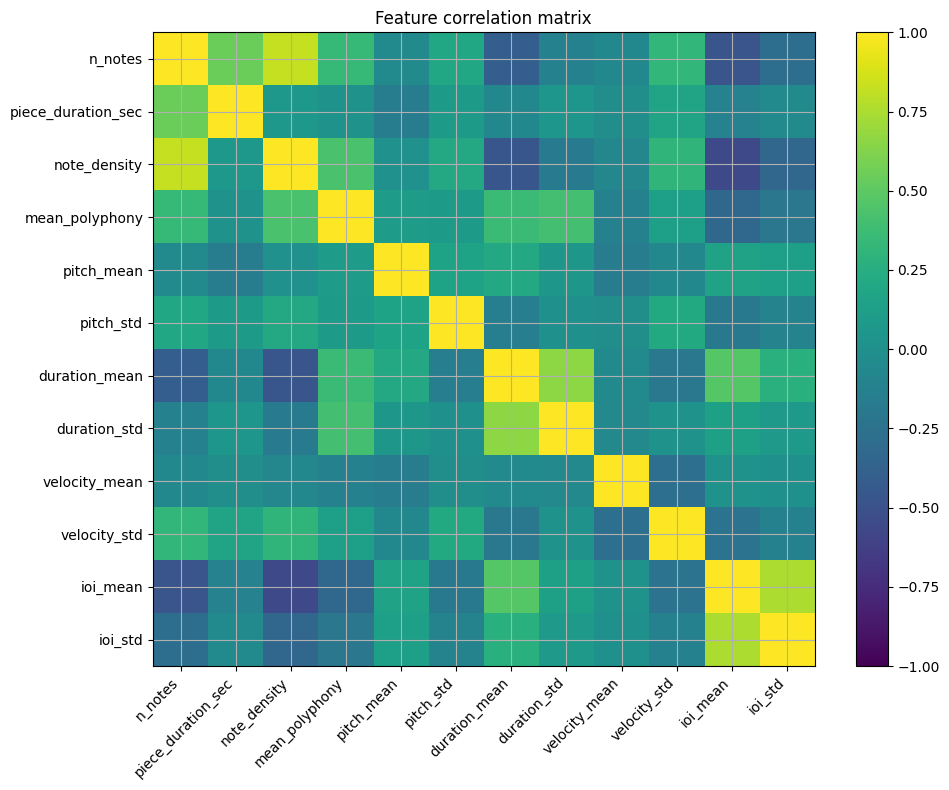

In [ ]:
corr_features = [
    "n_notes",
    "piece_duration_sec",
    "note_density",
    "mean_polyphony",
    "pitch_mean",
    "pitch_std",
    "duration_mean",
    "duration_std",
    "velocity_mean",
    "velocity_std",
    "ioi_mean",
    "ioi_std",
]
corr = features_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Feature correlation matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## PCA projection of engineered features

In [23]:
feature_cols = [c for c in features_df.columns if c not in {"sample_id", "genre", "emotion"}]
X = features_df[feature_cols].fillna(0.0).to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.17101942 0.09587035]
Total explained variance: 0.26688975


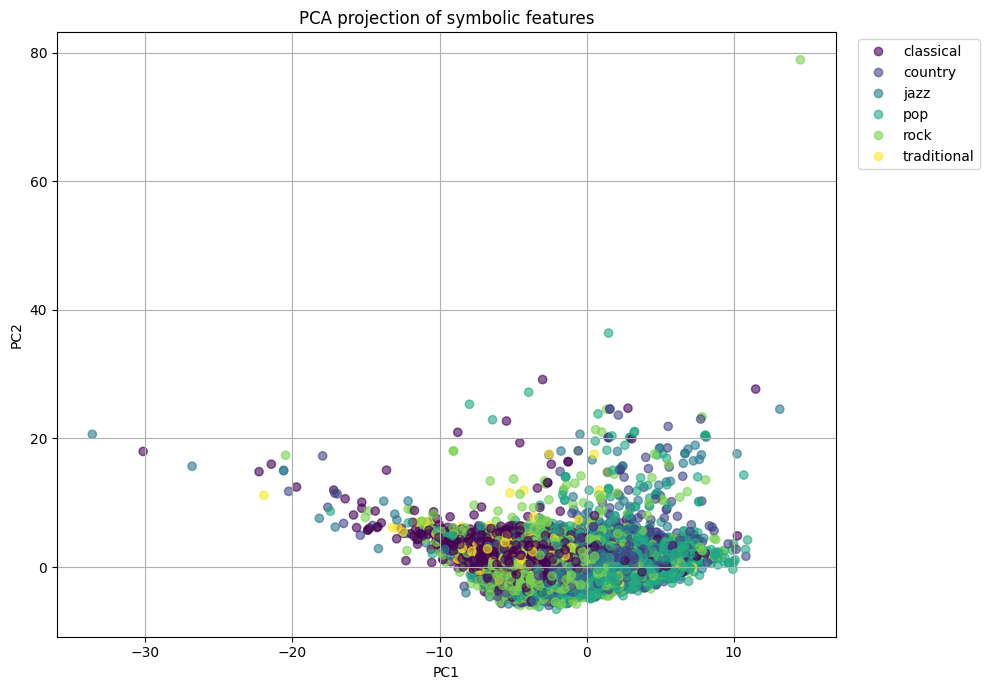

In [ ]:
genres = sorted(features_df["genre"].unique())
genre_to_int = {g: i for i, g in enumerate(genres)}
colors = [genre_to_int[g] for g in features_df["genre"]]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap="viridis", alpha=0.6)

handles, _ = scatter.legend_elements()
ax.legend(handles, genres, bbox_to_anchor=(1.02, 1), loc="upper left")

ax.set_title("PCA projection of symbolic features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_pca_projection.png", dpi=150, bbox_inches="tight")
plt.show()

# Conclusions

## 1. Dataset quality and label balance

- The XMIDI subset contains **108,023** samples distributed across **6 genre classes**.
- The metadata are consistent with the processed dataset: there are **no missing `.npz` files** and **no duplicate `sample_id` values**.
- The genre distribution is imbalanced. `rock`, `pop`, and `country` are the largest classes, whereas `traditional` is much smaller. In the next steps, we will keep all splits **stratified** and handle the imbalance with **class weighting** or **balanced sampling**.

## 2. Distribution of engineered features

- The main symbolic descriptors (`n_notes`, `piece_duration_sec`, `note_density`, duration statistics, and IOI statistics) are **right-skewed** and contain outliers.
- Because of that, we will preprocess these variables with **`log1p`** or another power transform and then apply **standardization** or **robust scaling** before training classical models.

## 3. Genre-specific patterns

- `pop` has the highest average **note count** and **note density**.
- `country` shows the highest average **polyphony**.
- `classical` has the highest average **pitch level** and relatively long note durations, but lower density than `pop`.
- `traditional` is also located on the lower-density / longer-duration side of the feature space.
- These differences are useful, but they are gradual rather than fully separating the classes. We will therefore treat them as informative signals, not as features that are expected to solve the task on their own.

## 4. Tonal and structural descriptors

- Pitch-class histograms and time-normalized **PCPR** profiles capture stable tonal differences between genres. We will keep them as one of the main low-dimensional feature groups.
- **Estimated key** will be kept only as an auxiliary categorical descriptor, not as a main predictor.
- The piano-roll examples show clear differences in temporal texture: classical and jazz excerpts tend to exhibit broader melodic movement, whereas pop, rock, country, and traditional excerpts are more pattern-based.
- Based on this, we will also keep a time-dependent representation in the pipeline, since part of the genre information is clearly carried by temporal structure.

## 5. Implications for classification

- The correlation matrix shows noticeable redundancy: `n_notes` and `note_density` are strongly related, `duration_mean` and `duration_std` are closely coupled, and `ioi_mean` and `ioi_std` behave similarly.
- For shallow models, we will account for this with **regularization**, and if needed also with **feature selection** or **dimensionality reduction**.
- The first two PCA components explain only about **26.7%** of the variance and the genre classes still overlap substantially. We therefore take aggregated symbolic statistics as a **baseline representation**, not as the final one.
- The classification setup in the next stage will combine: **(1)** global symbolic summary features, **(2)** pitch-class / PCPR descriptors, and **(3)** a **time-dependent representation** such as a piano-roll encoder.
- If we use the `emotion` labels later on, we will handle their imbalance even more carefully than for the genre labels.
